# Multi-Disease Chest X-ray Dataset — Merge & Preprocessing
### Montgomery + Shenzhen (TB) + NIH Sample (Pneumonia, Pneumothorax, COPD/Emphysema)

This notebook combines **all three datasets** into a single multi-class dataset with
**5 classes**: `Normal`, `TB`, `Pneumonia`, `Pneumothorax`, `COPD`.

**What this notebook does:**
1. Loads Montgomery + Shenzhen → contributes `TB` and some `Normal` images
2. Loads the NIH sample dataset → contributes `Pneumonia`, `Pneumothorax`,
   `COPD` (using NIH's `Emphysema` label as the standard proxy for COPD, since
   COPD itself has no dedicated public CXR label), and more `Normal` images
3. Merges everything into one labeled table
4. Shows you the real class balance (⚠️ NIH's rarer classes will be small —
   this notebook flags that clearly so you know before you train)
5. Splits into stratified train/val/test (70/15/15)
6. Resizes + copies images into clean `train/<class>/`, `val/<class>/`,
   `test/<class>/` folders ready for training

**Before running, download and unzip all three:**
- Montgomery: https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-montgomery
- Shenzhen: https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-shenzhen
- NIH sample: https://www.kaggle.com/datasets/nih-chest-xrays/sample

Then set the three folder paths below.


## 1. Imports

In [1]:
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Set your paths

Edit these to match your machine. Each *_DIR should point to the top-level
unzipped folder of that dataset — everything below searches recursively, so
exact internal folder nesting doesn't matter.


In [2]:
# ---- EDIT THESE ----
MONTGOMERY_DIR = "./data/montgomery"       # <-- Montgomery folder path
SHENZHEN_DIR   = "./data/shenzhen"         # <-- Shenzhen folder path
NIH_SAMPLE_DIR = "./data/nih_sample"       # <-- NIH sample folder path (contains sample_labels.csv + images)
OUTPUT_DIR     = "./multi_disease_dataset" # <-- where clean train/val/test folders will be created
# --------------------

IMG_SIZE = 224     # 224 works well with MobileNetV2 / ResNet / VGG
                   # drop to 160 if you need faster preprocessing / less disk usage

RANDOM_SEED = 42

# Target classes for this project
TARGET_CLASSES = ["Normal", "TB", "Pneumonia", "Pneumothorax", "COPD"]

# Cap on how many "Normal" images we keep overall, since Normal is heavily
# overrepresented across all three sources combined. Set to None to keep all.
MAX_NORMAL_IMAGES = 1200


## 3. Load Montgomery + Shenzhen (TB + Normal)

Both datasets use the same filename convention:

```
<PREFIX>_XXXX_0.png   -> label 0 = Normal
<PREFIX>_XXXX_1.png   -> label 1 = Tuberculosis
```


In [3]:
def build_tb_dataframe(root_dir, source_name):
    pattern = os.path.join(root_dir, "**", "*.png")
    all_files = glob.glob(pattern, recursive=True)

    records = []
    label_re = re.compile(r"_(\d)\.png$")

    for f in all_files:
        match = label_re.search(os.path.basename(f))
        if match is None:
            continue
        label = int(match.group(1))
        if label not in (0, 1):
            continue
        records.append({
            "filepath": f,
            "class_name": "TB" if label == 1 else "Normal",
            "source": source_name
        })

    df = pd.DataFrame(records)
    print(f"{source_name}: found {len(df)} images "
          f"({(df['class_name']=='TB').sum()} TB, {(df['class_name']=='Normal').sum()} Normal)")
    return df


montgomery_df = build_tb_dataframe(MONTGOMERY_DIR, "Montgomery")
shenzhen_df   = build_tb_dataframe(SHENZHEN_DIR, "Shenzhen")

if len(montgomery_df) == 0:
    print("\n⚠️  No images found in MONTGOMERY_DIR — double check the path.")
if len(shenzhen_df) == 0:
    print("\n⚠️  No images found in SHENZHEN_DIR — double check the path.")


Montgomery: found 138 images (58 TB, 80 Normal)
Shenzhen: found 662 images (336 TB, 326 Normal)


## 4. Load NIH sample dataset (Pneumonia, Pneumothorax, COPD/Emphysema, Normal)

The NIH sample dataset ships with a CSV (usually `sample_labels.csv`) containing
an `Image Index` column and a `Finding Labels` column. Labels can be
pipe-separated for images with multiple conditions (e.g. `"Pneumonia|Infiltration"`).

To keep this a clean **multi-class** (not multi-label) dataset, we only keep
images with a **single** finding that matches one of our target classes, plus
`"No Finding"` images (mapped to `Normal`). This avoids ambiguous labels
where an image has a condition we care about *and* one we're ignoring.

`Emphysema` is used as the standard public proxy for `COPD`, since there is no
dedicated public COPD label in CXR datasets.


In [4]:
def find_nih_labels_csv(root_dir):
    candidates = glob.glob(os.path.join(root_dir, "**", "*.csv"), recursive=True)
    for c in candidates:
        try:
            cols = pd.read_csv(c, nrows=0).columns
            if "Finding Labels" in cols and "Image Index" in cols:
                return c
        except Exception:
            continue
    return None


def build_nih_dataframe(root_dir):
    csv_path = find_nih_labels_csv(root_dir)
    if csv_path is None:
        print("⚠️  Could not find a labels CSV under NIH_SAMPLE_DIR — check the path.")
        return pd.DataFrame(columns=["filepath", "class_name", "source"])

    print(f"Using labels file: {csv_path}")
    labels_df = pd.read_csv(csv_path)

    # Map NIH's raw label -> our target class name
    label_map = {
        "Pneumonia": "Pneumonia",
        "Pneumothorax": "Pneumothorax",
        "Emphysema": "COPD",
        "No Finding": "Normal",
    }

    # Build an index of every image file under root_dir: filename -> full path
    all_images = glob.glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
    image_index = {os.path.basename(p): p for p in all_images}

    records = []
    for _, row in labels_df.iterrows():
        raw_labels = str(row["Finding Labels"])
        # Only keep single-label rows (no "|") to avoid ambiguous multi-condition images
        if "|" in raw_labels:
            continue
        if raw_labels not in label_map:
            continue

        fname = row["Image Index"]
        if fname not in image_index:
            continue  # image referenced in CSV but not present in this sample

        records.append({
            "filepath": image_index[fname],
            "class_name": label_map[raw_labels],
            "source": "NIH"
        })

    df = pd.DataFrame(records)
    print("NIH sample — usable single-label images per class:")
    print(df["class_name"].value_counts() if len(df) else "  (none found)")
    return df


nih_df = build_nih_dataframe(NIH_SAMPLE_DIR)


Using labels file: ./data/nih_sample\sample_labels.csv
NIH sample — usable single-label images per class:
class_name
Normal          3044
Pneumothorax     114
COPD              42
Pneumonia         14
Name: count, dtype: int64


## 5. Merge all three sources

Combines TB/Normal (Montgomery + Shenzhen) with Pneumonia/Pneumothorax/COPD/Normal
(NIH), and caps the total number of `Normal` images so it doesn't dominate the
other classes.


In [5]:
combined_df = pd.concat([montgomery_df, shenzhen_df, nih_df], ignore_index=True)
combined_df = combined_df[combined_df["class_name"].isin(TARGET_CLASSES)].reset_index(drop=True)

print("Class counts BEFORE capping Normal:")
print(combined_df["class_name"].value_counts())

if MAX_NORMAL_IMAGES is not None:
    normal_mask = combined_df["class_name"] == "Normal"
    normal_rows = combined_df[normal_mask]
    other_rows = combined_df[~normal_mask]

    if len(normal_rows) > MAX_NORMAL_IMAGES:
        normal_rows = normal_rows.sample(n=MAX_NORMAL_IMAGES, random_state=RANDOM_SEED)

    combined_df = pd.concat([other_rows, normal_rows], ignore_index=True)

print("\nClass counts AFTER capping Normal:")
print(combined_df["class_name"].value_counts())
print(f"\nTotal images: {len(combined_df)}")


Class counts BEFORE capping Normal:
class_name
Normal          3450
TB               394
Pneumothorax     114
COPD              42
Pneumonia         14
Name: count, dtype: int64

Class counts AFTER capping Normal:
class_name
Normal          1200
TB               394
Pneumothorax     114
COPD              42
Pneumonia         14
Name: count, dtype: int64

Total images: 1764


## 6. ⚠️ Check class balance before going further

NIH's rarer classes (especially Pneumonia) are naturally uncommon even in the
full 112K dataset, so in the 5,606-image sample they will be **small** — often
just a few dozen to a couple hundred images. This cell shows you exactly where
you stand.

**If any class has fewer than ~100 images**, consider either:
- pulling additional images for just that class from the full NIH ChestX-ray14
  dataset (filter `Data_Entry_2017.csv` for that label only, so you don't need
  to download all 45GB), or
- using the RSNA Pneumonia Detection Challenge dataset instead of NIH for the
  Pneumonia class specifically (it's dedicated to pneumonia and much larger)


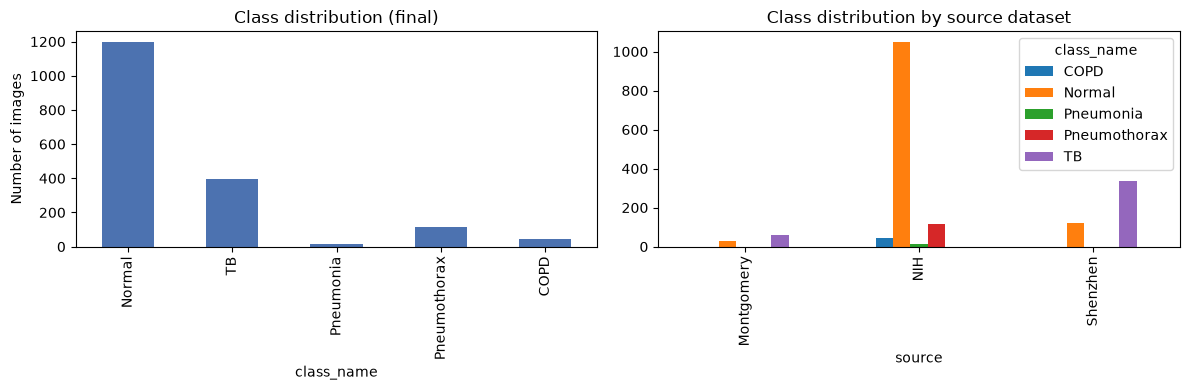


Final counts per class:
  Normal        :  1200
  TB            :   394
  Pneumonia     :    14  ⚠️ LOW — consider adding more data
  Pneumothorax  :   114
  COPD          :    42  ⚠️ LOW — consider adding more data


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

combined_df["class_name"].value_counts().reindex(TARGET_CLASSES).plot(
    kind="bar", ax=ax[0], color="#4C72B0"
)
ax[0].set_title("Class distribution (final)")
ax[0].set_ylabel("Number of images")

combined_df.groupby(["source", "class_name"]).size().unstack(fill_value=0).plot(
    kind="bar", ax=ax[1]
)
ax[1].set_title("Class distribution by source dataset")

plt.tight_layout()
plt.show()

print("\nFinal counts per class:")
for c in TARGET_CLASSES:
    n = (combined_df["class_name"] == c).sum()
    flag = "  ⚠️ LOW — consider adding more data" if n < 100 else ""
    print(f"  {c:14s}: {n:5d}{flag}")


## 7. Stratified train / validation / test split

70% train, 15% validation, 15% test, stratified by class so the ratio of all
5 classes stays consistent across splits.


In [7]:
train_df, temp_df = train_test_split(
    combined_df,
    test_size=0.30,
    stratify=combined_df["class_name"],
    random_state=RANDOM_SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=RANDOM_SEED
)

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test:  {len(test_df)} images")

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name} class balance: {df['class_name'].value_counts().to_dict()}")


Train: 1234 images
Val:   265 images
Test:  265 images
  Train class balance: {'Normal': 839, 'TB': 276, 'Pneumothorax': 80, 'COPD': 29, 'Pneumonia': 10}
  Val class balance: {'Normal': 181, 'TB': 59, 'Pneumothorax': 17, 'COPD': 6, 'Pneumonia': 2}
  Test class balance: {'Normal': 180, 'TB': 59, 'Pneumothorax': 17, 'COPD': 7, 'Pneumonia': 2}


## 8. Resize + copy images into `train/`, `val/`, `test/` folders

Creates:

```
multi_disease_dataset/
    train/
        Normal/  TB/  Pneumonia/  Pneumothorax/  COPD/
    val/
        Normal/  TB/  Pneumonia/  Pneumothorax/  COPD/
    test/
        Normal/  TB/  Pneumonia/  Pneumothorax/  COPD/
```

Images are resized to `IMG_SIZE x IMG_SIZE`, converted to RGB, and saved as JPEG.
Only resizing happens here — augmentation and pixel normalization are left for
training time so you can adjust them without re-running preprocessing.


In [8]:
def process_and_copy(df, split_name):
    for class_name in TARGET_CLASSES:
        out_dir = os.path.join(OUTPUT_DIR, split_name, class_name)
        os.makedirs(out_dir, exist_ok=True)

    for i, row in df.iterrows():
        try:
            img = Image.open(row["filepath"]).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

            base = os.path.splitext(os.path.basename(row["filepath"]))[0]
            out_name = f"{row['source']}_{base}.jpg"
            out_path = os.path.join(OUTPUT_DIR, split_name, row["class_name"], out_name)
            img.save(out_path, "JPEG", quality=95)
        except Exception as e:
            print(f"Skipped {row['filepath']}: {e}")

    print(f"{split_name}: processed {len(df)} images -> {os.path.join(OUTPUT_DIR, split_name)}")


os.makedirs(OUTPUT_DIR, exist_ok=True)

process_and_copy(train_df, "train")
process_and_copy(val_df, "val")
process_and_copy(test_df, "test")

print("\nAll done. Preprocessed dataset saved to:", os.path.abspath(OUTPUT_DIR))


train: processed 1234 images -> ./multi_disease_dataset\train
val: processed 265 images -> ./multi_disease_dataset\val
test: processed 265 images -> ./multi_disease_dataset\test

All done. Preprocessed dataset saved to: d:\Coding\healzy\xray\multi_disease_dataset


## 9. Sanity check — verify output folder counts

In [9]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}:")
    for class_name in TARGET_CLASSES:
        folder = os.path.join(OUTPUT_DIR, split, class_name)
        n = len(os.listdir(folder)) if os.path.exists(folder) else 0
        print(f"  {class_name:14s}: {n} images")



TRAIN:
  Normal        : 1047 images
  TB            : 359 images
  Pneumonia     : 10 images
  Pneumothorax  : 80 images
  COPD          : 29 images

VAL:
  Normal        : 237 images
  TB            : 110 images
  Pneumonia     : 2 images
  Pneumothorax  : 17 images
  COPD          : 6 images

TEST:
  Normal        : 240 images
  TB            : 110 images
  Pneumonia     : 2 images
  Pneumothorax  : 17 images
  COPD          : 7 images


## 10. Preview sample images from each class

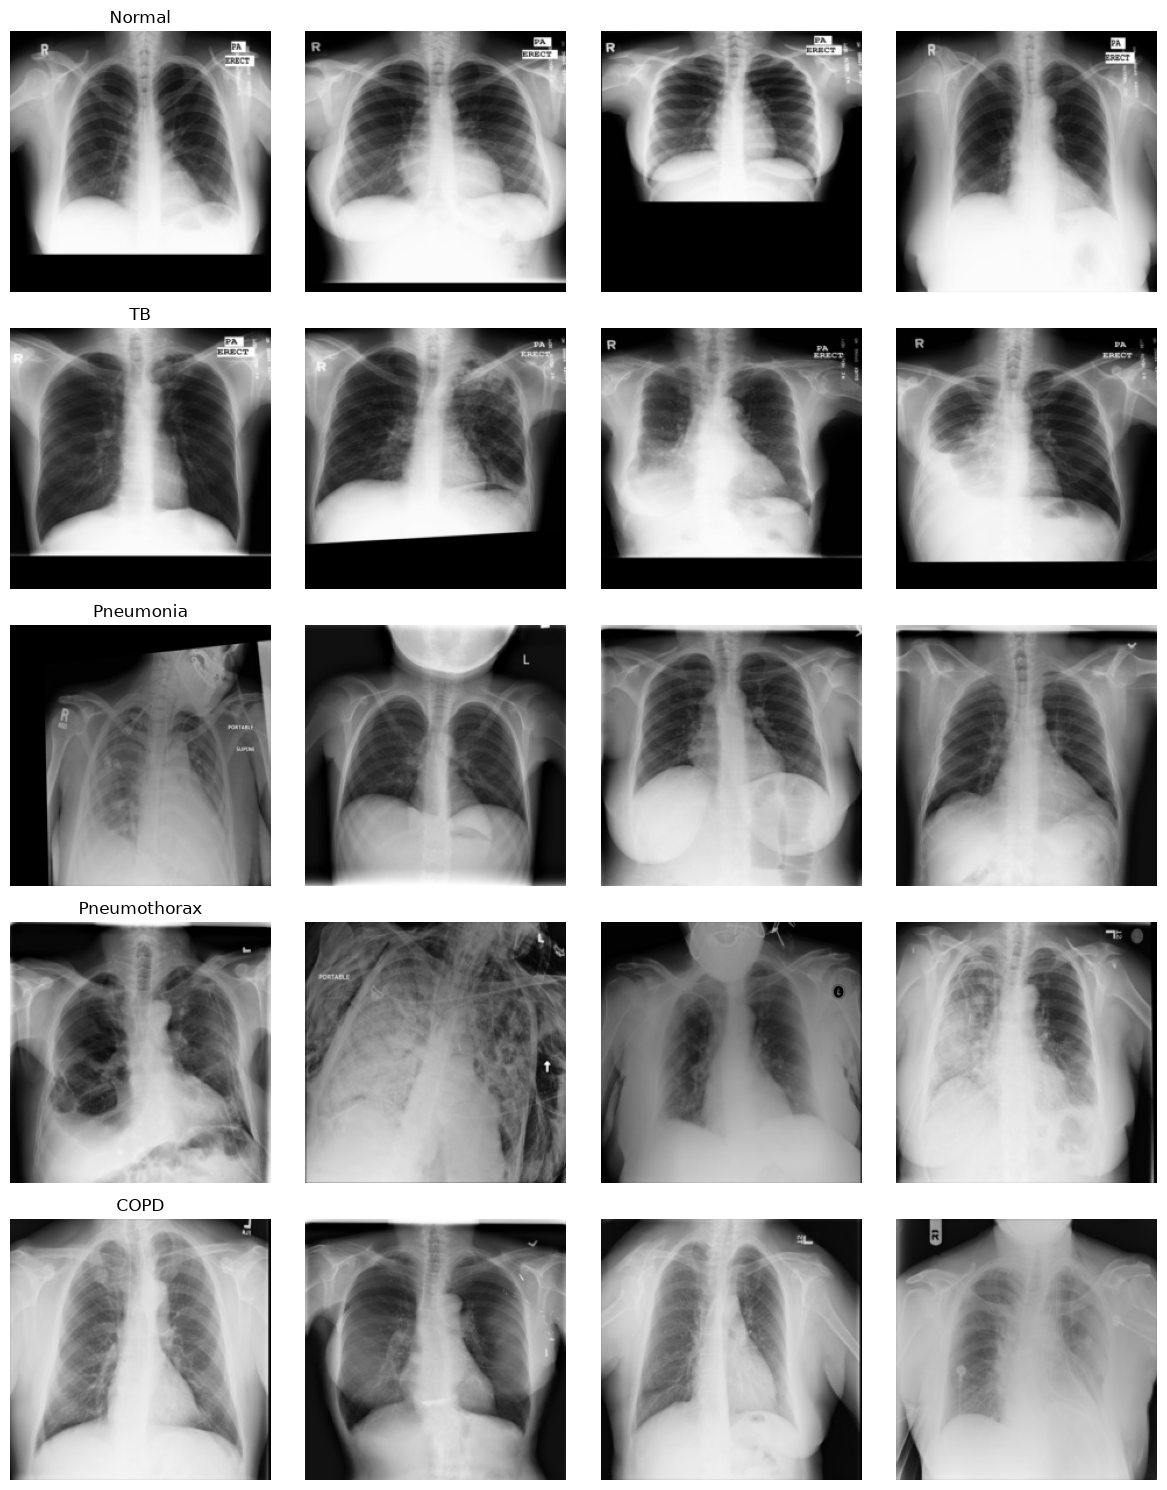

In [10]:
def show_samples(split="train", n=4):
    fig, axes = plt.subplots(len(TARGET_CLASSES), n, figsize=(3 * n, 3 * len(TARGET_CLASSES)))
    for row_idx, class_name in enumerate(TARGET_CLASSES):
        folder = os.path.join(OUTPUT_DIR, split, class_name)
        files = os.listdir(folder)[:n] if os.path.exists(folder) else []
        for col_idx in range(n):
            ax = axes[row_idx, col_idx]
            if col_idx < len(files):
                img = Image.open(os.path.join(folder, files[col_idx]))
                ax.imshow(img)
            ax.set_title(class_name if col_idx == 0 else "")
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples("train", n=4)


## 11. Next steps — you're ready to train

Your preprocessed data lives in `multi_disease_dataset/train`, `/val`, `/test`,
each with 5 class subfolders — the format `image_dataset_from_directory()` /
`ImageDataGenerator.flow_from_directory()` expects for **categorical**
(multi-class) classification.

Loading example for your next notebook:

```python
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "multi_disease_dataset/train",
    image_size=(224, 224),
    batch_size=16,
    label_mode="categorical"   # one-hot, since we have 5 classes
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "multi_disease_dataset/val",
    image_size=(224, 224),
    batch_size=16,
    label_mode="categorical"
)
```

**Because this dataset is imbalanced** (some NIH classes will be much smaller
than others even after capping Normal), the training notebook will use
`class_weight` in `model.fit()` to compensate — this is the standard approach
rather than duplicating/upsampling images at the preprocessing stage.

Next: MobileNetV2-based transfer learning model, frozen base, tuned for your
GTX 1650 4GB (batch size 16, 224x224 input).
